# PCA vs. Kernel PCA: When Do We Need the Kernel?

In this notebook we compare **standard PCA** and **kernel PCA** on two synthetic datasets:

1. **Linearly separable clusters** in $\mathbb{R}^{10}$ — the class structure lives in a low-dimensional
   linear subspace, so ordinary PCA captures it perfectly.
2. **Concentric rings** in $\mathbb{R}^{10}$ — the classes are separated by a *nonlinear* boundary,
   so PCA projections mix them together while an RBF kernel PCA teases them apart.

We use scikit-learn throughout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_blobs, make_circles
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

COLORS = {0: '#2196F3', 1: '#FF5722'}   # blue / orange-red

## Helper: side-by-side scatter of PCA vs. Kernel PCA projections

In [2]:
def compare_projections(X, y, title_prefix, gamma=None):
    """
    Fit standard PCA (2 components) and RBF kernel PCA (2 components)
    to the data X, then plot the two projections side by side.
    """
    # ---------- Standard PCA ----------
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # ---------- Kernel PCA (RBF) ----------
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
    X_kpca = kpca.fit_transform(X)

    # ---------- Plot ----------
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, Z, method in zip(axes, [X_pca, X_kpca], ['PCA', 'Kernel PCA (RBF)']):
        for label in np.unique(y):
            mask = y == label
            ax.scatter(Z[mask, 0], Z[mask, 1],
                       c=COLORS[label], label=f'Class {label}',
                       s=30, alpha=0.7, edgecolors='w', linewidths=0.3)
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.set_title(f'{title_prefix} — {method}')
        ax.legend()

    plt.tight_layout()
    plt.show()

    # Variance explained (available for linear PCA only)
    print(f'Linear PCA explained variance ratio: '
          f'{pca.explained_variance_ratio_.round(4)}')
    return pca, kpca

---
## Dataset 1: Linearly Separable Clusters

We generate two well-separated blobs in $\mathbb{R}^{10}$, with the true
cluster centres offset along a single direction. Standard PCA should
capture the separation in its first component.

In [3]:
# Two blobs in R^10 whose centres are well-separated along the
# first two coordinates.  We keep cluster_std small relative to
# the centre offset so that the separation survives scaling.
centers = np.zeros((2, 10))
centers[0, :2] = [ 5.0,  4.0]   # class 0
centers[1, :2] = [-5.0, -4.0]   # class 1

X_blobs, y_blobs = make_blobs(
    n_samples=500, centers=centers, cluster_std=0.8, random_state=42
)
X_blobs = StandardScaler().fit_transform(X_blobs) # The StandardScalar is a common preprocessing step, but isn't always good.

print(f'X shape: {X_blobs.shape}')
print(f'Class counts: {np.bincount(y_blobs)}')

X shape: (500, 10)
Class counts: [250 250]


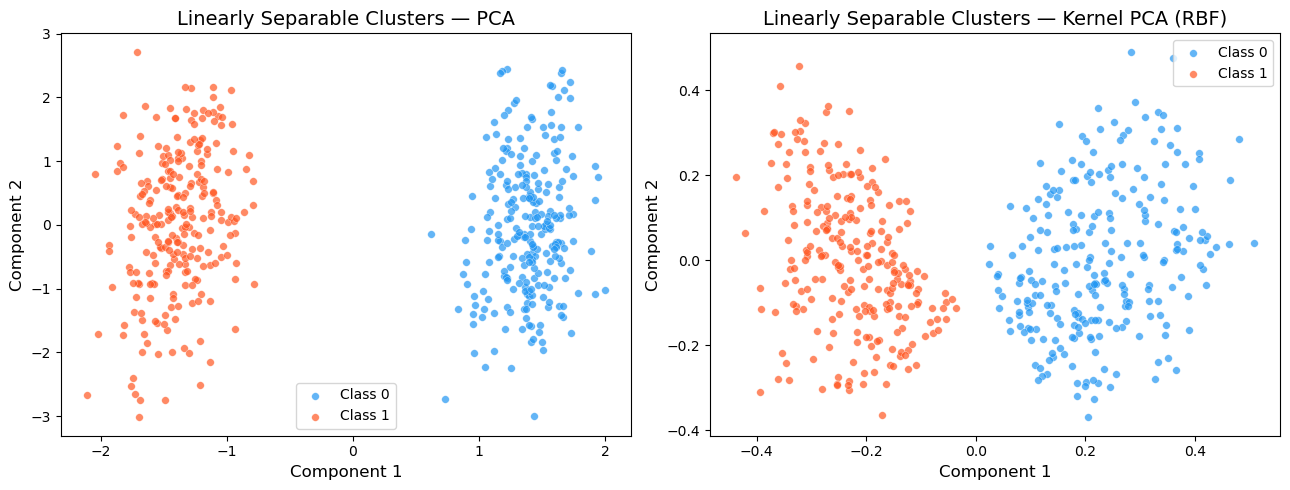

Linear PCA explained variance ratio: [0.1993 0.1187]


In [14]:
pca_lin, kpca_lin = compare_projections(
    X_blobs, y_blobs, 'Linearly Separable Clusters', gamma=0.15
)

**Observation.** Both PCA and kernel PCA separate the classes cleanly. The explained-variance ratios for PC 1–2 are modest (roughly 20% and 12%) because the eight pure-noise dimensions still carry substantial variance. Nevertheless, the top two components capture the two signal directions where the cluster centers are offset, so a simple linear boundary in the PC 1–2 plane classifies the points nearly perfectly. The kernel adds nothing here — standard PCA wins on interpretability and speed.

---
## Dataset 2: Concentric Rings

Now we generate two concentric circles in $\mathbb{R}^2$ and embed
them into $\mathbb{R}^{6}$ by appending low-variance Gaussian noise dimensions.
The class boundary is a *circle*, not a hyperplane, so linear PCA
cannot separate the classes in any 2-D projection.

In [ ]:
# Concentric circles in R^2, then embed into R^6
# by appending 4 low-variance noise dimensions.
X_circ_2d, y_circ = make_circles(
    n_samples=600, factor=0.3, noise=0.05, random_state=42
)

# Keep the noise small so the circle structure dominates.
# We do NOT standardize here — scaling would equalize the
# noise dims with the circle dims, destroying the radial gap
# that kernel PCA needs to exploit.
noise_dims = 0.05 * np.random.RandomState(42).randn(600, 4)
X_rings = np.hstack([X_circ_2d, noise_dims])

# Xrings = StandardScaler().fit_transform(X_rings)  # This can destroy the structure of nonlinear data in some cases, such as off-center rings. Other times it can be helpful, but here it doesn't do anything.

# X_rings += np.array([[5, 0, 0, 0,0,0]] * X_circ_2d.shape[0]) #shift the rings to the right (Claude thinks bad, Copilot thinks good))
# X_rings[:, 1] *= 10 # stretch the rings vertically to make them more elongated and less circular (Claude thinks bad or good, Copilot thinks good)
# Xrings = StandardScaler().fit_transform(X_rings)

print(f'X shape: {X_rings.shape}')
print(f'Class counts: {np.bincount(y_circ)}')

X shape: (600, 6)
Class counts: [300 300]


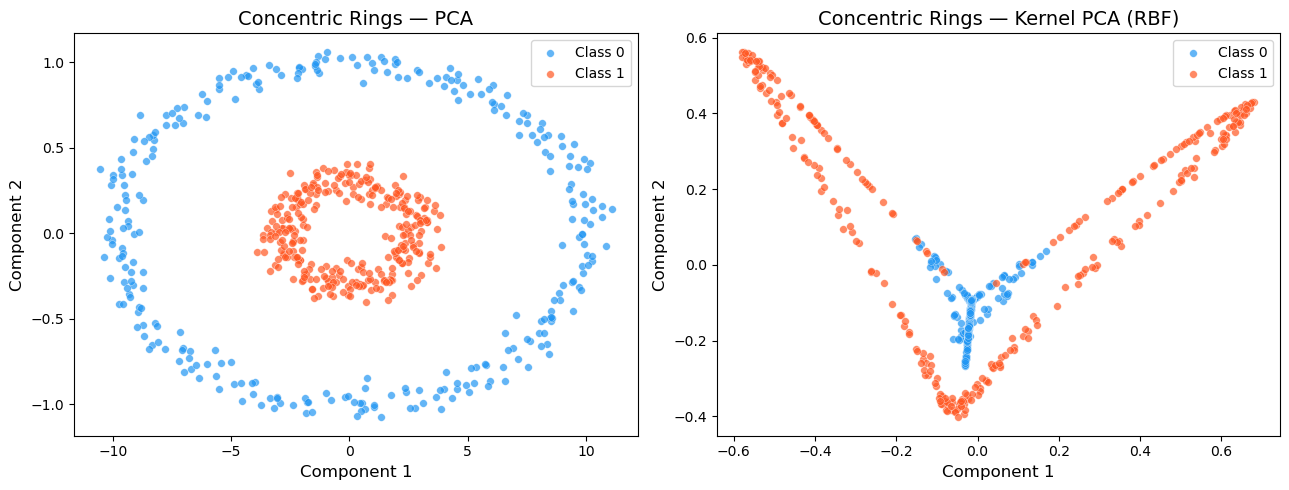

Linear PCA explained variance ratio: [0.9897 0.0099]


In [39]:
pca_nl, kpca_nl = compare_projections(
    X_rings, y_circ, 'Concentric Rings', gamma=2
)

**Observation.** Standard PCA filters out the extra noise dimensions, but
there is no linear direction that separates an inner circle from an outer
circle. Kernel PCA with an RBF kernel "unfolds" the nonlinear structure
and maps the two classes into clearly separated regions.

---
## Sensitivity to $\gamma$

The RBF kernel $k(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \|\mathbf{x}-\mathbf{x}'\|^2)$
has a single hyperparameter $\gamma$ that controls the width of the kernel.
Too small → everything looks similar (flat embedding); too large → interesting weird things happen. 
Let's sweep $\gamma$ on the rings data.

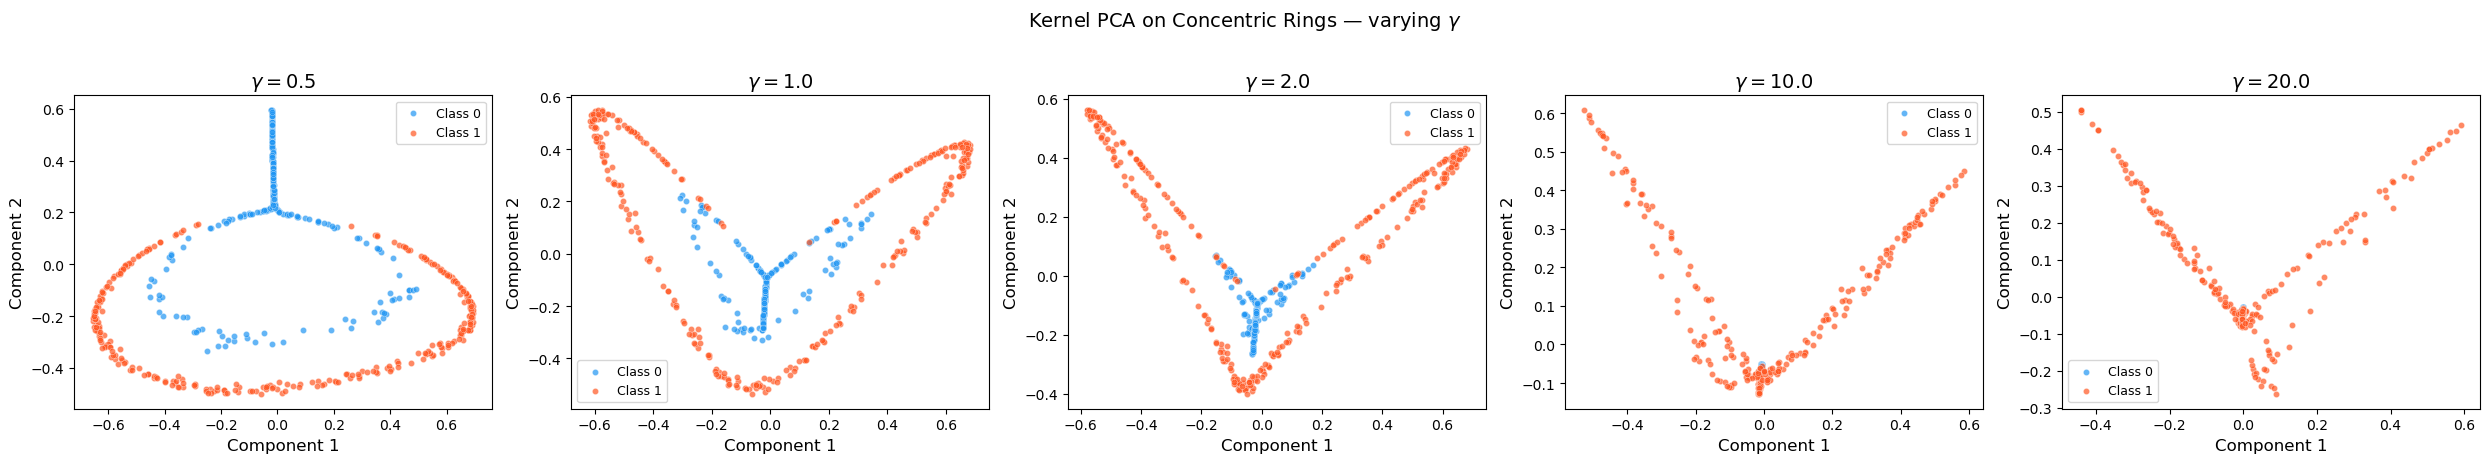

In [40]:
gammas = [0.5, 1.0, 2.0, 10.0, 20.0]

fig, axes = plt.subplots(1, len(gammas), figsize=(5 * len(gammas), 4.5))

for ax, g in zip(axes, gammas):
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=g)
    Z = kpca.fit_transform(X_rings)
    for label in [0, 1]:
        mask = y_circ == label
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=COLORS[label], s=20, alpha=0.7,
                   edgecolors='w', linewidths=0.3,
                   label=f'Class {label}')
    ax.set_title(f'$\\gamma = {g}$')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend(fontsize=9)

fig.suptitle('Kernel PCA on Concentric Rings — varying $\\gamma$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation.** Small $\gamma$  produces a wide kernel that can't resolve the gap between rings; $\gamma ≈ 2$ hits the sweet spot; large $\gamma$ over-resolves distant points and distorts the embedding.

---
## Summary

| Scenario | PCA | Kernel PCA |
|---|---|---|
| Linearly separable clusters | Clean separation in PC 1 | Can separate, but no advantage |
| Concentric rings (nonlinear boundary) | Classes overlap in every linear projection | RBF kernel unfolds the nonlinear structure |

**Take-aways:**

- Use standard PCA first — it's fast, interpretable (explained variance), and sufficient when
  the class structure lives in a linear subspace.
- Switch to kernel PCA when PCA projections show overlapping classes that you believe
  are separated by a nonlinear boundary.
- The kernel bandwidth $\gamma$ matters a lot; cross-validation or visual inspection is
  essential for tuning it.

**A note on preprocessing.** We standardize the blob data (`StandardScaler`: zero mean, unit variance per feature) because PCA is sensitive to feature scale, and the default preprocessing puts every dimension on equal footing. The cluster separation survives because the between-class gap is large relative to the within-class spread, even after rescaling.

We deliberately *skip* standardization for the rings. Here the class structure is encoded in the radius $\|\mathbf{x}\|$, not in any single coordinate's variance. Forcing every axis to unit variance inflates the noise dimensions to the same scale as the circle dimensions, destroying the radial gap that the RBF kernel needs to exploit.

**Take-away:** Standardization is a sensible default for variance-based methods (PCA, SVM), but when the signal lives in the *geometry* of the data — distances, radii, angles — independent per-feature rescaling can erase the very structure you are trying to find.
